In [3]:
import numpy as np

import pandas as pd

import cv2

import os

import random

import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras.applications import VGG19

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Dropout
)

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("train.csv")
df = df[["id", "landmark_id"]]


In [5]:
df

,id,landmark_id
0,6e158a47eb2ca3f6,142820
1,202cd79556f30760,104169
2,3ad87684c99c06e1,37914
3,e7f70e9c61e66af3,102140
4,4072182eddd0100e,2474
...,...,...
4132909,fc0f007893b11ba7,172138
4132910,39aad18585867916,162860
4132911,fd0725460e4ebbec,191243
4132912,73691ae29e24ba19,145760


In [6]:
samples = 20000

df = df.loc[:samples, :]



In [7]:
num_classes = len(df["landmark_id"].unique())
num_data = len(df)
print(num_classes)
print(num_data)

16342
20001


In [8]:
data = pd.DataFrame(df["landmark_id"].value_counts())

data.reset_index(inplace=True)

data.head()

,landmark_id,count
0,138982,57
1,177870,22
2,62798,20
3,192931,16
4,171772,14


In [9]:
data.tail()

,landmark_id,count
16337,30748,1
16338,174045,1
16339,76112,1
16340,18915,1
16341,4406,1


In [10]:
data.columns = ["landmark_id", "count"]

(array([0.0000e+00, 1.3867e+04, 0.0000e+00, 1.8470e+03, 0.0000e+00,
        4.0500e+02, 0.0000e+00, 1.2300e+02, 3.9000e+01, 0.0000e+00,
        2.5000e+01, 0.0000e+00, 1.5000e+01, 0.0000e+00, 6.0000e+00,
        3.0000e+00, 0.0000e+00, 4.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 3.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

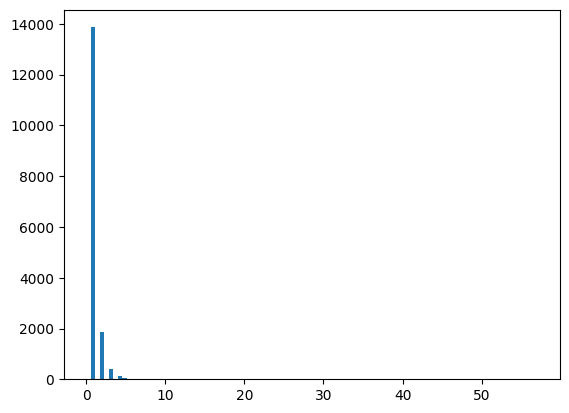

In [11]:
plt.hist(data['count'], 100, range=(0,57), label='test')



In [12]:
int(data['count'].between(0,5).sum())

16281

In [13]:
int(data['count'].between(5,10).sum())

92

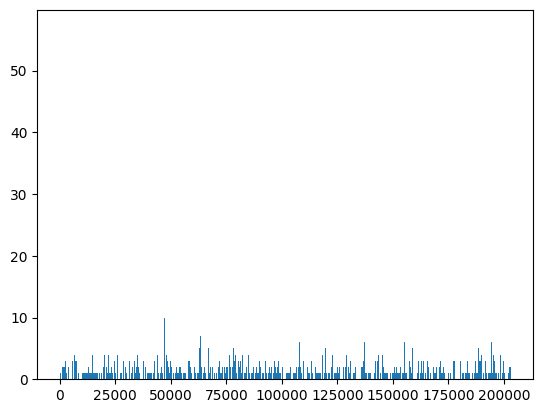

In [14]:
plt.hist(df["landmark_id"], bins=df["landmark_id"].nunique())

plt.show()

In [15]:
lencoder = LabelEncoder()

lencoder.fit(df["landmark_id"])

LabelEncoder()

In [16]:
def encode_label(lbl):

    return lencoder.transform(lbl)

In [17]:
def decode_label(lbl):

    return lencoder.inverse_transform(lbl)

In [18]:
base_path = "train"

In [19]:
def get_image_from_number(i, df):

    image_id = df.iloc[i]["id"]

    file_name = image_id + ".jpg"

    found_path = None

    for root, dirs, files in os.walk(base_path):

        if file_name in files:

            found_path = os.path.join(root, file_name)

            break

    if found_path is None:

        raise FileNotFoundError(file_name)

    im = cv2.imread(found_path)

    label = df.iloc[i]["landmark_id"]

    return im, label

4 Sample images from random classes


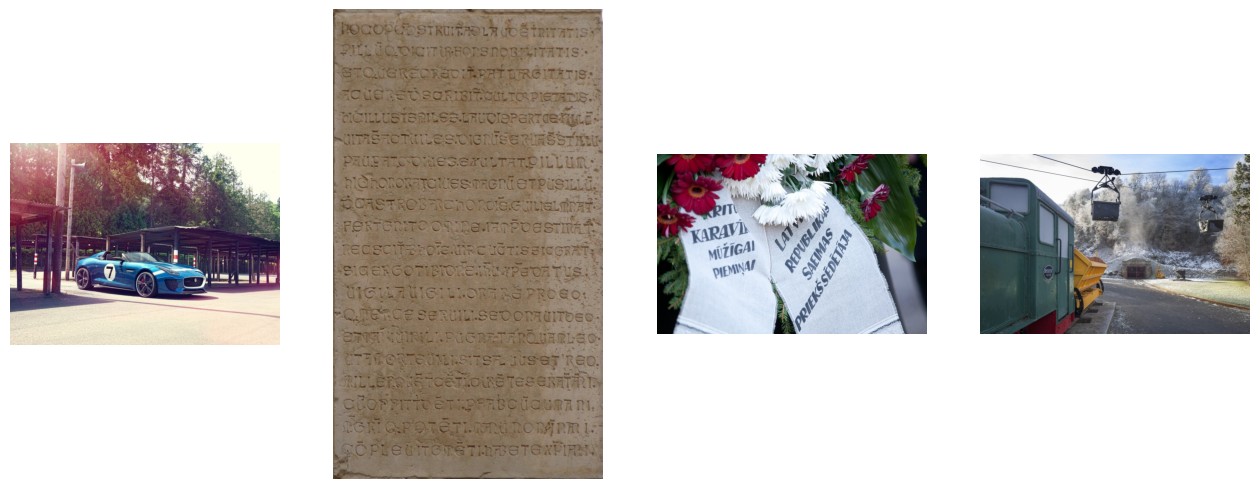

In [20]:
print("4 Sample images from random classes")

fig = plt.figure(figsize=(16,16))

image_files = []

for root, dirs, files in os.walk(base_path):

    for file in files:

        if file.endswith((".jpg", ".jpeg", ".png")):

            image_files.append(os.path.join(root, file))

random_images = random.sample(image_files, 4)

for i, img_path in enumerate(random_images, 1):

    img = np.array(Image.open(img_path))

    fig.add_subplot(1,4,i)

    plt.imshow(img)

    plt.axis('off')

plt.show()

In [21]:
def image_reshape(im, target_size):

    return cv2.resize(im, target_size)

In [22]:
images = []
labels = []

target_size = (224,224)

In [23]:
print(base_path)

train


In [24]:
base_path = "/Users/sarikamisra/Desktop/Landmark_Project/train"

print(base_path)

/Users/sarikamisra/Desktop/Landmark_Project/train


In [25]:
def get_image_from_number(i, df):

    image_id = df.iloc[i]["id"]

    file_name = image_id + ".jpg"

    found_path = None

    for root, dirs, files in os.walk(base_path):

        if file_name in files:

            found_path = os.path.join(root, file_name)

            break

    if found_path is None:

        return None, None

    im = cv2.imread(found_path)

    label = df.iloc[i]["landmark_id"]

    return im, label

In [28]:
import pandas as pd
import os

image_ids = []

for root, dirs, files in os.walk(base_path):

    for file in files:

        if file.endswith(".jpg"):

            image_id = file.replace(".jpg", "")

            image_ids.append(image_id)

df = pd.DataFrame({
    "id": image_ids,
    "landmark_id": [0]*len(image_ids)
})

df.head()

,id,landmark_id
0,009562d7711c7fe8,0
1,00987a32dd849d9b,0
2,0098e87bc23e4a0e,0
3,0093c2d262d21e18,0
4,00971a30839a2f1e,0


In [35]:
images = []
labels = []

for i in range(100):

    try:

        im, label = get_image_from_number(i, df)

        if im is not None:

            im = image_reshape(im, target_size)

            images.append(im)

            labels.append(label)

    except:

        pass

print(len(images))
print(len(labels))

100
100


In [36]:
X = np.array(images, dtype="float32") / 255.0

y = np.array(labels)

In [37]:
from sklearn.preprocessing import LabelEncoder
lencoder = LabelEncoder()
y = lencoder.fit_transform(y)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/anaconda3/envs/tfenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    X,
    y,
    epochs = 3,
    batch_size = 1,
    verbose = 1
)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 1.0000 - loss: 1.3270e-23
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 1.0000 - loss: 1.3268e-23
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 1.0000 - loss: 1.3268e-23


In [43]:
model.save("landmark_detection_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted: [0]
Actual: 0


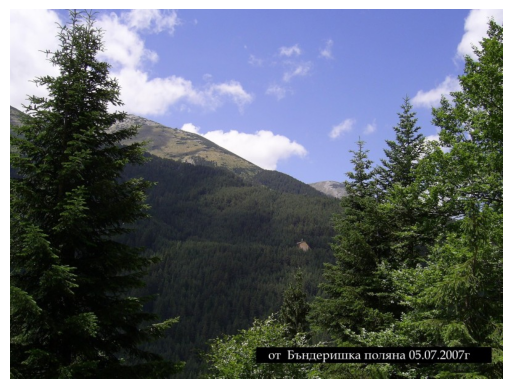

In [44]:
img, label = get_image_from_number(5, df)

img2 = image_reshape(img, (224,224))

img2 = np.expand_dims(img2/255.0, axis=0)

pred = model.predict(img2)

print("Predicted:", decode_label([np.argmax(pred)]))

print("Actual:", label)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted: [0]
Actual: 0


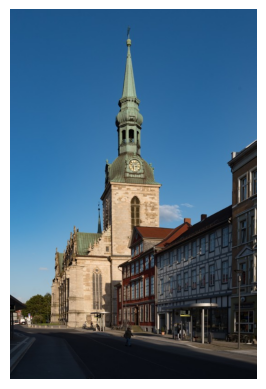

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted: [0]
Actual: 0


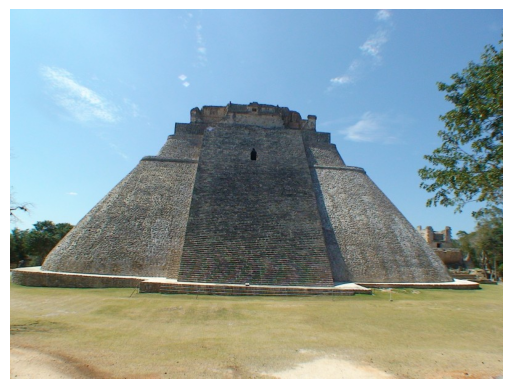

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted: [0]
Actual: 0


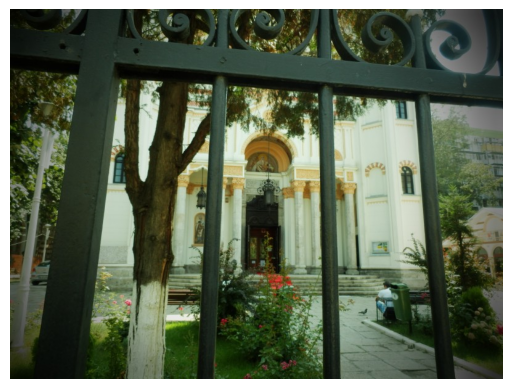

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted: [0]
Actual: 0


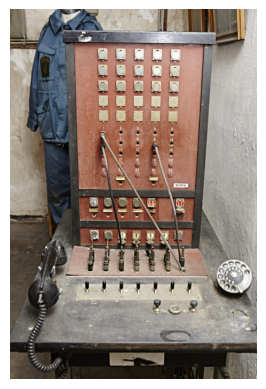

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted: [0]
Actual: 0


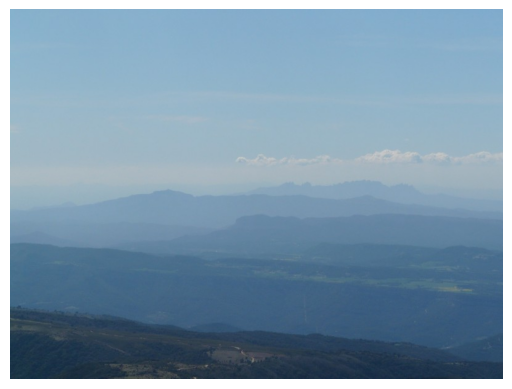

In [45]:
for i in range(5):

    img, label = get_image_from_number(random.randint(0, len(df)-1), df)

    img2 = image_reshape(img, (224,224))

    img2 = np.expand_dims(img2/255.0, axis=0)

    pred = model.predict(img2)

    print("Predicted:", decode_label([np.argmax(pred)]))

    print("Actual:", label)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.axis("off")

    plt.show()

In [47]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Validation Accuracy: 1.0


In [48]:
model.save("landmark_detection_model.keras")

In [49]:
from tensorflow.keras.models import load_model

saved_model = load_model("landmark_detection_model.keras")

/opt/anaconda3/envs/tfenv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted: [0]
Actual: 0


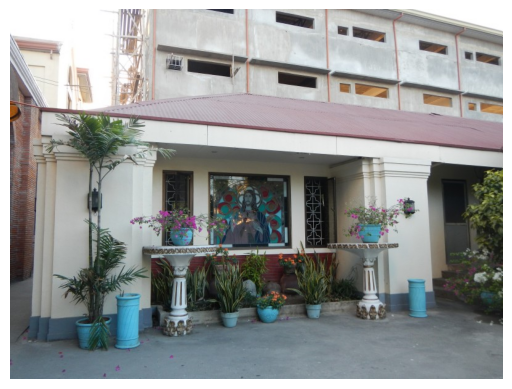

In [50]:
img, label = get_image_from_number(10, df)

img2 = image_reshape(img, (224,224))

img2 = np.expand_dims(img2/255.0, axis=0)

pred = saved_model.predict(img2)

print("Predicted:", decode_label([np.argmax(pred)]))

print("Actual:", label)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

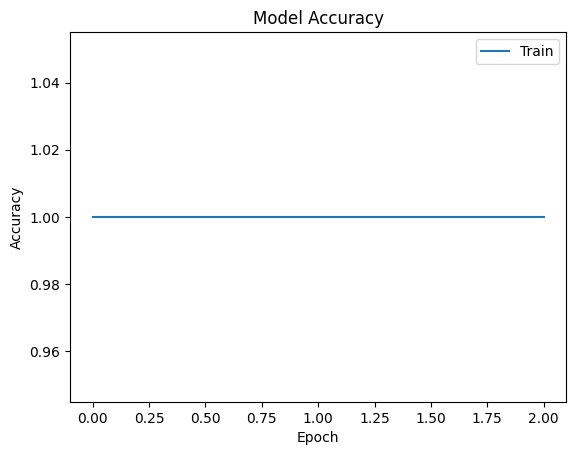

In [54]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])

plt.title("Model Accuracy")

plt.ylabel("Accuracy")

plt.xlabel("Epoch")

plt.legend(['Train'])

plt.show()

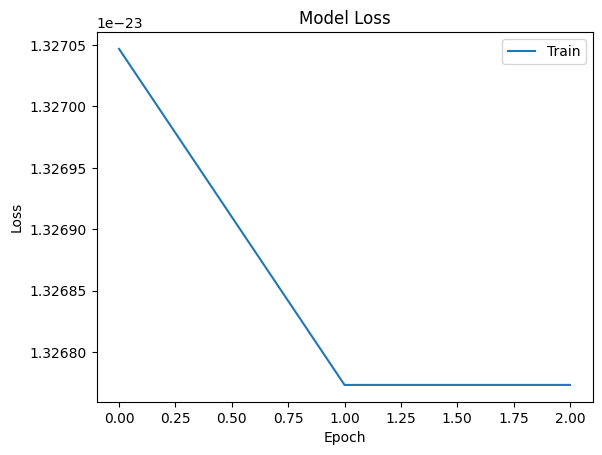

In [55]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

plt.title("Model Loss")

plt.ylabel("Loss")

plt.xlabel("Epoch")

plt.legend(['Train'])

plt.show()